In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from itertools import product
import wandb
from cnn import CNN

In [10]:

# Custom Dataset for ChestMNIST
class ChestMNISTDataset(Dataset):
    def __init__(self, npz_file, transform=None):
        data = np.load(npz_file)
        self.images = data['images']  # Zakładamy klucz 'images' dla obrazów
        self.labels = data['labels']  # Zakładamy klucz 'labels' dla etykiet
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Konwersja numpy.ndarray na PIL.Image
        image = Image.fromarray(image)

        # Jeśli podano transformacje, zastosuj je
        if self.transform:
            image = self.transform(image)

        return image, label


# Update training and evaluation functions to log metrics to wandb
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device).float()
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    average_loss = running_loss / len(train_loader)
    wandb.log({"Train Loss": average_loss})
    return average_loss


def evaluate(model, test_loader, criterion, device, threshold=0.5):
    model.eval()
    test_loss = 0.0
    total = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device).float()
            outputs = model(data)
            test_loss += criterion(outputs, target).item()

            # Sigmoid to calculate probabilities
            predictions = torch.sigmoid(outputs) > threshold
            correct += (predictions == target.bool()).sum().item()
            total += target.numel()

    test_loss /= len(test_loader)
    accuracy = correct / total
    
    wandb.log({"Validation Loss": test_loss, "Validation Accuracy": accuracy})
    return test_loss, accuracy

# Early Stopping Training Loop
def early_stopping_training(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, patience=5):
    best_val_loss = float('inf')
    trigger_times = 0
    train_losses = []
    val_losses = []
    accuracies = []

    for epoch in range(epochs):
        train_loss = train(model, train_loader, criterion, optimizer, device)
        val_loss, accuracy = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        accuracies.append(accuracy)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}")

        # Log metrics to wandb
        wandb.log({"Epoch": epoch + 1, "Train Loss": train_loss, "Validation Loss": val_loss, "Validation Accuracy": accuracy})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            trigger_times += 1
            print(f"No improvement for {trigger_times}/{patience} epochs")

        if trigger_times >= patience:
            print("Early stopping triggered!")
            break

    model.load_state_dict(torch.load("best_model.pth", weights_only=True))
    return train_losses, val_losses, accuracies

In [11]:
# Hyperparameters and device setup
batch_size = 64
epochs = 10
learning_rate = 0.001
weight_decay = 0.0001
patience = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 14
fraction = 0.05

learning_rates = [1e-4, 1e-3, 1e-2]
batch_sizes = [32, 64, 128]
weight_decays = [1e-4, 1e-3]
gridsearch = True

In [12]:
# Initialize Weights & Biases project
wandb.init(project="chestmnist", config={
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rates": learning_rates,
    "weight_decays": weight_decays
})

In [13]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # Losowe odbicie poziome
    transforms.RandomRotation(degrees=15),  # Losowy obrót o +/- 15 stopni
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)),  # Losowy crop i skalowanie
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalizacja
])


train_dataset = ChestMNISTDataset("data/chestmnist_train_64x64.npz", transform=transform)
val_dataset = ChestMNISTDataset("data/chestmnist_val_64x64.npz", transform=transform)
test_dataset = ChestMNISTDataset("data/chestmnist_test_64x64.npz", transform=transform)

# Wyliczenie liczby próbek
train_size = int(len(train_dataset) * fraction)
val_size = int(len(val_dataset) * fraction)
test_size = int(len(test_dataset) * fraction)

# Losowy wybór indeksów
train_indices = np.random.choice(len(train_dataset), train_size, replace=False)
val_indices = np.random.choice(len(val_dataset), val_size, replace=False)
test_indices = np.random.choice(len(test_dataset), test_size, replace=False)

# Tworzenie podzbiorów
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)
test_subset = Subset(test_dataset, test_indices)

# DataLoader dla podzbiorów
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

Training with lr=0.0001, batch_size=64, weight_decay=0.0001


Epoch 1/10, Train Loss: 0.3088, Val Loss: 0.1823, Accuracy: 0.9500
Epoch 2/10, Train Loss: 0.1810, Val Loss: 0.1812, Accuracy: 0.9500
Epoch 3/10, Train Loss: 0.1815, Val Loss: 0.1800, Accuracy: 0.9500
Epoch 4/10, Train Loss: 0.1797, Val Loss: 0.1784, Accuracy: 0.9500
Epoch 5/10, Train Loss: 0.1784, Val Loss: 0.1779, Accuracy: 0.9500
Epoch 6/10, Train Loss: 0.1778, Val Loss: 0.1776, Accuracy: 0.9500
Epoch 7/10, Train Loss: 0.1771, Val Loss: 0.1766, Accuracy: 0.9500
Epoch 8/10, Train Loss: 0.1757, Val Loss: 0.1755, Accuracy: 0.9500
Epoch 9/10, Train Loss: 0.1763, Val Loss: 0.1752, Accuracy: 0.9500
Epoch 10/10, Train Loss: 0.1748, Val Loss: 0.1770, Accuracy: 0.9500
No improvement for 1/3 epochs


Epoch,▁▂▃▃▄▅▆▆▇█
Train Loss,██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation Loss,██▇▇▆▆▄▄▄▄▃▃▂▂▁▁▁▁▃▃
Epoch,10
Train Loss,0.17477
Validation Accuracy,0.95
Validation Loss,0.17705


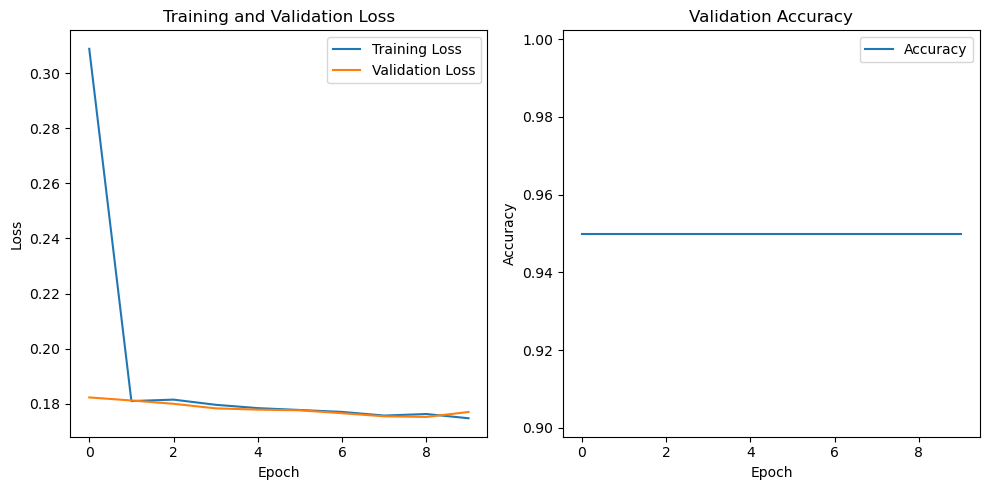

In [14]:
# Initialize model, loss, and optimizer
model = CNN(num_classes).to(device)
criterion = nn.BCEWithLogitsLoss()

# Training and testing loop
train_losses = []
val_losses = []
accuracies = []

if gridsearch:
    for lr, batch_size, wd in product(learning_rates, batch_sizes, weight_decays):
        print(f"Training with lr={lr}, batch_size={batch_size}, weight_decay={wd}")

        # Log hyperparameters to wandb
        wandb.init(project="grid_search", config={"learning_rate": lr, "batch_size": batch_size, "weight_decay": wd})

        model = CNN(num_classes=14).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

        train_losses, val_losses, accuracies = early_stopping_training(
            model, train_loader, val_loader, criterion, optimizer, device, epochs, patience
        )
        
        wandb.finish()
else:
    lr = 0.0001
    batch_size = 64
    weight_decay = 1e-4

    print(f"Training with lr={lr}, batch_size={batch_size}, weight_decay={weight_decay}")

    # Log hyperparameters to wandb
    wandb.init(project="single_run", config={"learning_rate": lr, "batch_size": batch_size, "weight_decay": weight_decay})

    model = CNN(num_classes=14).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

    train_losses, val_losses, accuracies = early_stopping_training(
        model, train_loader, val_loader, criterion, optimizer, device, epochs, patience
    )
    
    wandb.finish()


# Plotting the training progress
plt.figure(figsize=(10, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
from torchsummary import summary
summary(model, input_size=(1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             320
              ReLU-2           [-1, 32, 64, 64]               0
         MaxPool2d-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          18,496
              ReLU-5           [-1, 64, 32, 32]               0
         MaxPool2d-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
              ReLU-8          [-1, 128, 16, 16]               0
         MaxPool2d-9            [-1, 128, 8, 8]               0
           Linear-10                  [-1, 128]       1,048,704
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 14]           1,806
Total params: 1,143,182
Trainable params: 1,143,182
Non-trainable params: 0
---------------------------